# BloodMNIST — exploring the dataset for swarm learning

`dataset/bloodmnist.npz` (MedMNIST v2). Peripheral blood cell microscopy: 17,092 images,
8 cell types, 28x28 RGB, already split 7:1:2 into train/val/test.

Picked for three reasons:

- **small** — 34 MB, trains on a CPU, so a full swarm round takes seconds
- **8 classes** — enough to build a genuinely non-IID split across nodes
- **medical** — matches the swarm learning literature this project builds on
  (Warnat-Herresthal et al., *Nature* 2021, used blood transcriptomes)

This notebook answers what the data looks like, then how to hand each node a
different slice of it — the input the swarm loop needs.

Download (already done once, the file is gitignored):

```bash
curl -L -o dataset/bloodmnist.npz \
  https://huggingface.co/datasets/albertvillanova/medmnist-v2/resolve/main/data/bloodmnist.npz
```


In [1]:
import collections

import matplotlib.pyplot as plt
import numpy as np

DATA = np.load("dataset/bloodmnist.npz")

CLASS_NAMES = [
    "basophil",
    "eosinophil",
    "erythroblast",
    "immature granulocytes",
    "lymphocyte",
    "monocyte",
    "neutrophil",
    "platelet",
]

X_train, y_train = DATA["train_images"], DATA["train_labels"].ravel()
X_val, y_val = DATA["val_images"], DATA["val_labels"].ravel()
X_test, y_test = DATA["test_images"], DATA["test_labels"].ravel()

for name, X, y in (("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)):
    print(f"{name:5s}  X={str(X.shape):20s} {X.dtype}  y={str(y.shape):10s} {y.dtype}  "
          f"range=[{X.min()}, {X.max()}]")

train  X=(11959, 28, 28, 3)   uint8  y=(11959,)   uint8  range=[0, 255]
val    X=(1712, 28, 28, 3)    uint8  y=(1712,)    uint8  range=[0, 255]
test   X=(3421, 28, 28, 3)    uint8  y=(3421,)    uint8  range=[0, 255]


## Class balance

The split is imbalanced at the source: neutrophils and eosinophils are roughly 2.7x more
common than basophils. Worth knowing before blaming the swarm for a skewed model —
part of the skew is in the data to begin with.


class                          train    val   test  train %
0 basophil                       852    122    244     7.1%
1 eosinophil                    2181    312    624    18.2%
2 erythroblast                  1085    155    311     9.1%
3 immature granulocytes         2026    290    579    16.9%
4 lymphocyte                     849    122    243     7.1%
5 monocyte                       993    143    284     8.3%
6 neutrophil                    2330    333    666    19.5%
7 platelet                      1643    235    470    13.7%
total                          11959   1712   3421


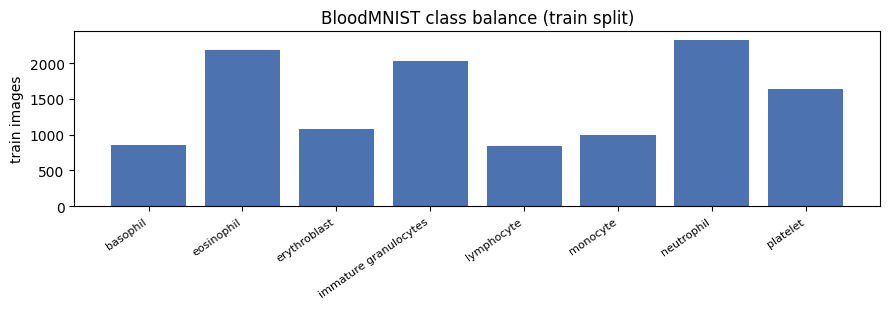

In [2]:
counts = {
    split: np.bincount(y, minlength=len(CLASS_NAMES))
    for split, y in (("train", y_train), ("val", y_val), ("test", y_test))
}

print(f"{'class':28s} {'train':>7s} {'val':>6s} {'test':>6s} {'train %':>8s}")
for i, name in enumerate(CLASS_NAMES):
    share = 100 * counts["train"][i] / counts["train"].sum()
    print(f"{i} {name:26s} {counts['train'][i]:7d} {counts['val'][i]:6d} "
          f"{counts['test'][i]:6d} {share:7.1f}%")
print(f"{'total':28s} {counts['train'].sum():7d} {counts['val'].sum():6d} {counts['test'].sum():6d}")

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(range(len(CLASS_NAMES)), counts["train"], color="#4c72b0")
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("train images")
ax.set_title("BloodMNIST class balance (train split)")
fig.tight_layout()
plt.show()

## What the images look like

Eight samples per class. At 28x28 the cell body and the stain colour carry most of the
signal; fine nuclear texture is mostly gone, which caps how well any model can do here.


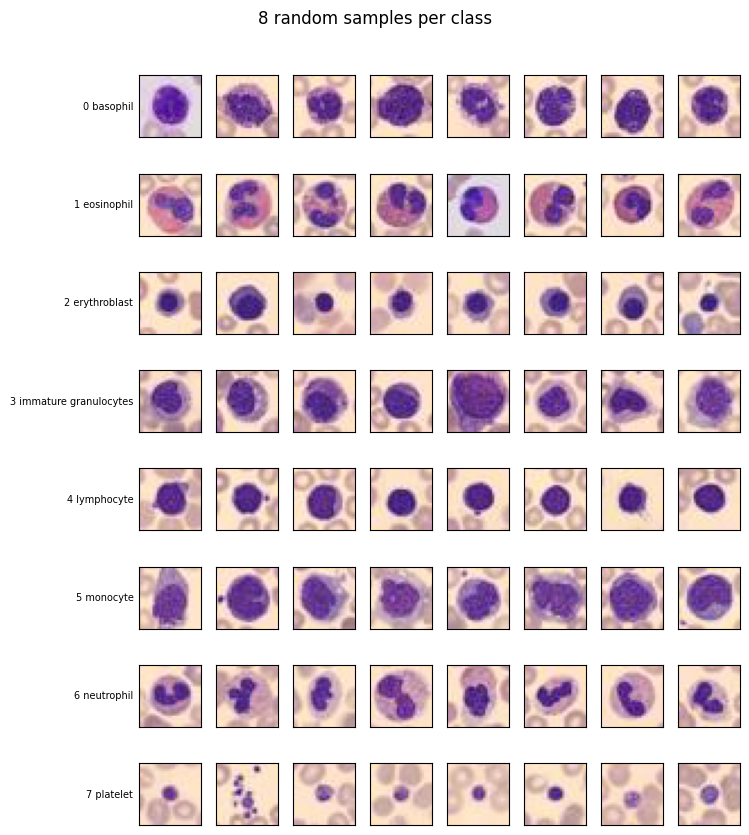

In [3]:
rng = np.random.default_rng(0)
n_show = 8

fig, axes = plt.subplots(len(CLASS_NAMES), n_show, figsize=(n_show * 0.95, len(CLASS_NAMES) * 1.05))
for row, name in enumerate(CLASS_NAMES):
    idx = rng.choice(np.where(y_train == row)[0], n_show, replace=False)
    for col, j in enumerate(idx):
        ax = axes[row, col]
        ax.imshow(X_train[j])
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(f"{row} {name}", rotation=0, ha="right", va="center", fontsize=7)
fig.suptitle("8 random samples per class", y=1.005)
fig.tight_layout()
plt.show()

## Pixel statistics

Per-channel means and standard deviations, for normalisation later. Every node must use
the **same** constants — derived from the public train split, never from a node's private
data, or the nodes would preprocess differently and averaging their weights would be
meaningless.


channel means: [0.7943 0.6597 0.6962]
channel stds : [0.2156 0.2416 0.1179]


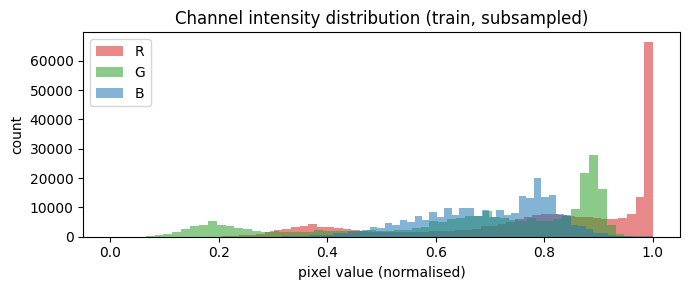

In [4]:
flat = X_train.reshape(-1, 3).astype(np.float64) / 255.0
mean, std = flat.mean(axis=0), flat.std(axis=0)
print("channel means:", np.round(mean, 4))
print("channel stds :", np.round(std, 4))

fig, ax = plt.subplots(figsize=(7, 3))
for c, colour in enumerate(("#d62728", "#2ca02c", "#1f77b4")):
    ax.hist(flat[::37, c], bins=60, alpha=0.55, color=colour, label="RGB"[c])
ax.set_xlabel("pixel value (normalised)"); ax.set_ylabel("count"); ax.legend()
ax.set_title("Channel intensity distribution (train, subsampled)")
fig.tight_layout()
plt.show()

## Splitting the data across swarm nodes

Each node in the swarm holds its own private slice and never shares it. How that slice is
built decides how hard the learning problem is:

- **IID** — shuffle and deal evenly. Every node sees the same class mix, so local models
  stay close together and FedAvg converges almost like central training. Not realistic.
- **non-IID** — each node's class mix is skewed, the way one hospital sees a different
  patient population than another. Local models drift apart between rounds and averaging
  them gets harder. This is the case worth reporting.

Below uses the standard Dirichlet partition: for each class, draw proportions from
`Dir(alpha)` over the nodes. Small `alpha` = extreme skew, large `alpha` approaches IID.


In [5]:
NODES = ["A", "B", "C", "D", "E"]


def dirichlet_partition(y, n_nodes, alpha, seed=42):
    """Split indices of y across nodes, skewing each class by a Dirichlet draw."""
    rng = np.random.default_rng(seed)
    shards = [[] for _ in range(n_nodes)]
    for cls in np.unique(y):
        idx = rng.permutation(np.where(y == cls)[0])
        proportions = rng.dirichlet(np.repeat(alpha, n_nodes))
        cuts = (np.cumsum(proportions) * len(idx)).astype(int)[:-1]
        for node, part in enumerate(np.split(idx, cuts)):
            shards[node].extend(part.tolist())
    return [np.array(sorted(s)) for s in shards]


ALPHA = 0.5
shards = dirichlet_partition(y_train, len(NODES), ALPHA)

matrix = np.array([np.bincount(y_train[s], minlength=len(CLASS_NAMES)) for s in shards])
print(f"Dirichlet alpha = {ALPHA}\n")
print(f"{'node':6s} {'n':>6s}  per-class counts")
for name, s, row in zip(NODES, shards, matrix):
    print(f"{name:6s} {len(s):6d}  {row}")
print(f"{'total':6s} {sum(len(s) for s in shards):6d}")

Dirichlet alpha = 0.5

node        n  per-class counts
A        2973  [265 145 784 865 237 225 139 313]
B        2637  [ 220 1531   26  158  298  271   19  114]
C        2189  [294 102   0 308  24 409 445 607]
D        1180  [  5 164 174   3  26  64 744   0]
E        2980  [ 68 239 101 692 264  24 983 609]
total   11959


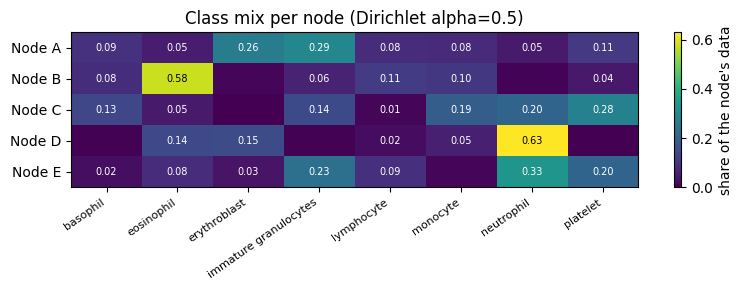

In [6]:
fig, ax = plt.subplots(figsize=(8, 3))
share = matrix / matrix.sum(axis=1, keepdims=True)
im = ax.imshow(share, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=35, ha="right", fontsize=8)
ax.set_yticks(range(len(NODES)))
ax.set_yticklabels([f"Node {n}" for n in NODES])
for i in range(len(NODES)):
    for j in range(len(CLASS_NAMES)):
        if share[i, j] > 0.01:
            ax.text(j, i, f"{share[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if share[i, j] < 0.5 else "black")
fig.colorbar(im, ax=ax, label="share of the node's data")
ax.set_title(f"Class mix per node (Dirichlet alpha={ALPHA})")
fig.tight_layout()
plt.show()

### How alpha changes the difficulty

One number per setting: the mean total-variation distance between a node's class
distribution and the global one. 0 means the node mirrors the whole dataset; higher means
its local optimum sits further from the global one, which is exactly what makes FedAvg
struggle.


In [7]:
global_dist = np.bincount(y_train, minlength=len(CLASS_NAMES)) / len(y_train)

print(f"{'alpha':>7s} {'mean TV distance':>18s} {'smallest node':>15s} {'largest node':>14s}")
for alpha in (0.1, 0.5, 1.0, 10.0, 100.0):
    parts = dirichlet_partition(y_train, len(NODES), alpha)
    dists, sizes = [], []
    for s in parts:
        local = np.bincount(y_train[s], minlength=len(CLASS_NAMES)) / max(len(s), 1)
        dists.append(0.5 * np.abs(local - global_dist).sum())
        sizes.append(len(s))
    print(f"{alpha:7.1f} {np.mean(dists):18.3f} {min(sizes):15d} {max(sizes):14d}")

  alpha   mean TV distance   smallest node   largest node
    0.1              0.667              22           4573
    0.5              0.377            1180           2980
    1.0              0.342            1078           3889
   10.0              0.085            2054           2912
  100.0              0.028            2261           2555


## What this costs the ledger

The chain never stores weights, only a hash of them (see `../sl-blockchain/README.md`).
Still, the model size decides how much traffic a round actually costs off-chain, and the
number of rounds decides how fast the chain grows. Both numbers belong in the report.


In [8]:
ROUNDS = 25
N_CLASSES = len(CLASS_NAMES)
N_FEATURES = 28 * 28 * 3  # flattened, as a linear baseline would see it

linear_params = N_CLASSES * N_FEATURES + N_CLASSES        # coef + intercept
linear_bytes = linear_params * 8                          # float64

print(f"linear baseline: {linear_params:,} parameters = {linear_bytes / 1024:,.1f} KiB per node per round")
print(f"one round, {len(NODES)} nodes: {len(NODES) * linear_bytes / 1024:,.1f} KiB off-chain")
print(f"{ROUNDS} rounds        : {ROUNDS * len(NODES) * linear_bytes / 1024 / 1024:,.2f} MiB off-chain")

on_chain_per_tx = 64 + 40  # sha256 hex + round/node/sample bookkeeping, roughly
on_chain_per_round = (len(NODES) + 1) * (on_chain_per_tx + 128)  # + ed25519 signature hex
print(f"\non-chain, per round : ~{on_chain_per_round:,} bytes")
print(f"on-chain, {ROUNDS} rounds : ~{ROUNDS * on_chain_per_round / 1024:,.1f} KiB")
print("\nthe gap between those two is the reason weights stay off-chain")

linear baseline: 18,824 parameters = 147.1 KiB per node per round
one round, 5 nodes: 735.3 KiB off-chain
25 rounds        : 17.95 MiB off-chain

on-chain, per round : ~1,392 bytes
on-chain, 25 rounds : ~34.0 KiB

the gap between those two is the reason weights stay off-chain


## Next

- The partition function above is what the swarm loop will call to hand each node its data
- `alpha` is the knob for the non-IID experiment: report accuracy against `alpha`, not just
  a single number
- Normalisation constants must come from this notebook, not from per-node statistics
